In [14]:
from pathlib import Path
import sys
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [15]:
import os
import pandas as pd

curr_folder = os.getcwd()

table_file_path = os.path.abspath(
    os.path.join(curr_folder, "..", "inputs", "Megeath_YSOs", "table4.dat.txt")
)

# Define the column names (based on the provided table headers, modifying the RA and DE columns)
column_names = ['Seq', 'RA_DEC', 'Jmag', 'e_Jmag', 'Hmag', 'e_Hmag',
                'Kmag', 'e_Kmag', '[3.6]', 'e_[3.6]', '[4.5]', 'e_[4.5]', '[5.8]', 'e_[5.8]',
                '[8.0]', 'e_[8.0]', '[24]', 'e_[24]', 'AKs', 'alpha', 'Cl']

# Read the file, skipping the first few lines, assuming fixed-width formatting
data = pd.read_fwf(table_file_path, skiprows=5, names=column_names, delimiter="|")

# Now split the 'RA_DEC' column into individual RA and DEC components based on spaces
# Assuming the format: "RAh RAm RAs DEd DEm DEs"
ra_dec_split = data['RA_DEC'].str.split(expand=True)

# Add the RA and DEC columns back to the DataFrame
data['RAh'] = 5
data['RAm'] = ra_dec_split[1].astype(float)
data['RAs'] = ra_dec_split[2].astype(float)
data['DEd'] = ra_dec_split[3].astype(float)
data['DEm'] = ra_dec_split[4].astype(float)
data['DEs'] = ra_dec_split[5].astype(float)

# Drop the original combined column
data.drop(columns=['RA_DEC'], inplace=True)

# Convert RA/DEC to decimal degrees
data['RA_deg'] = 15 * (data['RAh'] + data['RAm'] / 60 + data['RAs'] / 3600)
data['DEC_deg'] = data['DEd'] + np.sign(data['DEd'])*data['DEm'] / 60 + np.sign(data['DEd'])*data['DEs'] / 3600

# Handle negative declination degrees correctly
# data['DEC_deg'] = data.apply(lambda row: -row['DEC_deg'] if row['DEd'] < 0 else row['DEC_deg'], axis=1)

# Create SkyCoord object and transform to galactic coordinates
coords = SkyCoord(ra=data['RA_deg']*u.degree, dec=data['DEC_deg']*u.degree, frame='icrs', unit=u.degree)
data['l'] = coords.galactic.l.degree
data['b'] = coords.galactic.b.degree
# Orion A and Orion B
l_min_A, l_max_A = 206, 217
b_min_A, b_max_A = -21, -17

filtered_data_OA = data[(data['l'] >= 206) & (data['l'] <= 217) & (data['b'] >= -21) & (data['b'] <= -17)]

l_min_B, l_max_B = 203, 210
b_min_B, b_max_B = -17, -12

# Filter for objects within the specified galactic coordinates
filtered_data_OB = data[(data['l'] >= 203) & (data['l'] <= 210) & (data['b'] >= -17) & (data['b'] <= -12)]
# Display the first few rows to confirm
# print(data.iloc[1]['RAh'])

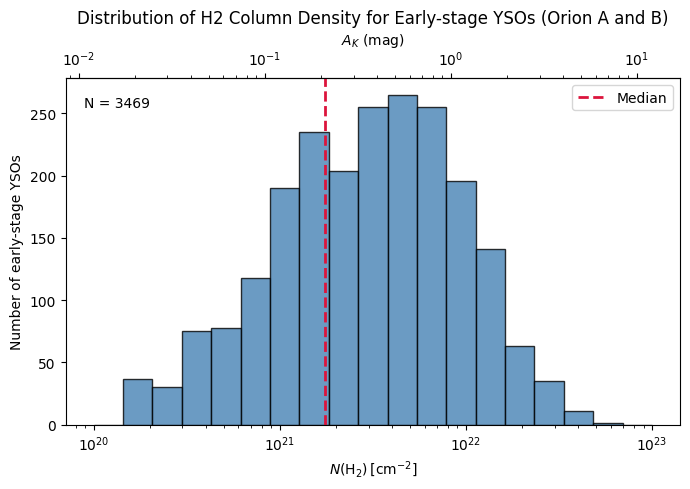

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Select early-stage YSOs
early = data["Cl"].isin(["D", "F", "P", "FP"])

ysos = data[early]

# Remove missing AKs values
ysos = ysos.dropna(subset=["AKs"])

Aks = pd.to_numeric(ysos["AKs"], errors="coerce")

# Convert to H2 column density
NH2 = 8.3e21 * Aks

bins = np.logspace(20, 23, 20)

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(NH2,
        bins=bins,
        color="steelblue",
        edgecolor="black",
        alpha=0.8)

ax.set_xscale("log")
ax.set_xlabel(r"$N(\mathrm{H}_2)\,[\mathrm{cm}^{-2}]$")
ax.set_ylabel("Number of early-stage YSOs")
ax.set_title("Distribution of H2 Column Density for Early-stage YSOs (Orion A and B)")

median = np.nanmedian(NH2)
ax.axvline(median, color="crimson", ls="--",
           lw=2, label="Median")

ax.text(0.03, 0.95,
        f"N = {len(NH2)}",
        transform=ax.transAxes,
        va="top")

ax.legend()

secax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: x/8.3e21,
               lambda x: x*8.3e21)
)
secax.set_xlabel(r"$A_K$ (mag)")

plt.tight_layout()
plt.show()

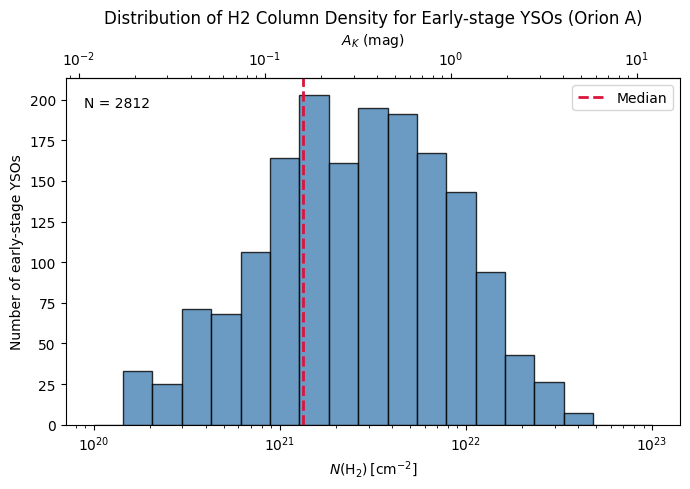

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# check this!

# Select early-stage YSOs
early = filtered_data_OA["Cl"].isin(["D", "F", "P", "FP"])

ysos = filtered_data_OA[early]

# Remove missing AKs values
ysos = ysos.dropna(subset=["AKs"])

Aks = pd.to_numeric(ysos["AKs"], errors="coerce")

# Convert to H2 column density
NH2 = 8.3e21 * Aks

bins = np.logspace(20, 23, 20)

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(NH2,
        bins=bins,
        color="steelblue",
        edgecolor="black",
        alpha=0.8)

ax.set_xscale("log")
ax.set_xlabel(r"$N(\mathrm{H}_2)\,[\mathrm{cm}^{-2}]$")
ax.set_ylabel("Number of early-stage YSOs")
ax.set_title("Distribution of H2 Column Density for Early-stage YSOs (Orion A)")

median = np.nanmedian(NH2)
ax.axvline(median, color="crimson", ls="--",
           lw=2, label="Median")

ax.text(0.03, 0.95,
        f"N = {len(NH2)}",
        transform=ax.transAxes,
        va="top")

ax.legend()

secax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: x/8.3e21,
               lambda x: x*8.3e21)
)
secax.set_xlabel(r"$A_K$ (mag)")

plt.tight_layout()
plt.show()

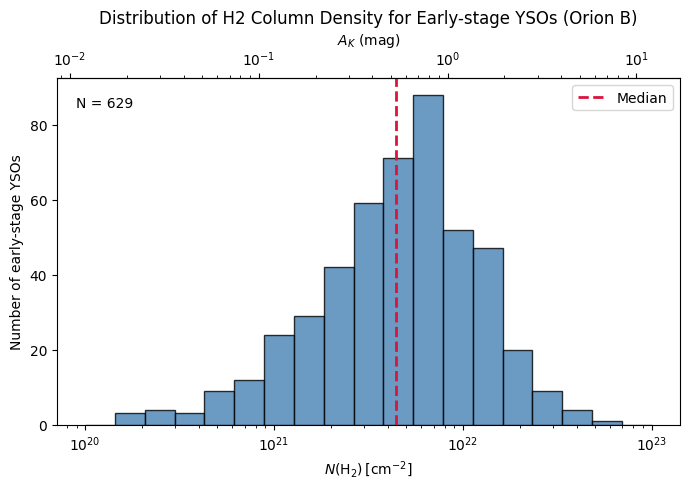

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# check this!

# Select early-stage YSOs
early = filtered_data_OB["Cl"].isin(["D", "F", "P", "FP"])

ysos = filtered_data_OB[early]

# Remove missing AKs values
ysos = ysos.dropna(subset=["AKs"])

Aks = pd.to_numeric(ysos["AKs"], errors="coerce")

# Convert to H2 column density
NH2 = 8.3e21 * Aks

bins = np.logspace(20, 23, 20)

fig, ax = plt.subplots(figsize=(7,5))

ax.hist(NH2,
        bins=bins,
        color="steelblue",
        edgecolor="black",
        alpha=0.8)

ax.set_xscale("log")
ax.set_xlabel(r"$N(\mathrm{H}_2)\,[\mathrm{cm}^{-2}]$")
ax.set_ylabel("Number of early-stage YSOs")
ax.set_title("Distribution of H2 Column Density for Early-stage YSOs (Orion B)")

median = np.nanmedian(NH2)
ax.axvline(median, color="crimson", ls="--",
           lw=2, label="Median")

ax.text(0.03, 0.95,
        f"N = {len(NH2)}",
        transform=ax.transAxes,
        va="top")

ax.legend()

secax = ax.secondary_xaxis(
    "top",
    functions=(lambda x: x/8.3e21,
               lambda x: x*8.3e21)
)
secax.set_xlabel(r"$A_K$ (mag)")

plt.tight_layout()
plt.show()